In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
%matplotlib inline
import time
import os

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import statsmodels
import seaborn as sns
#import bioinfokit
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.model_selection import StratifiedKFold,KFold
logo = LeaveOneGroupOut()
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import pickle

In [2]:
%run classifiers_functions.ipynb

# All cells marked with * are not necessary to facilitate routine analysis, they are for you to modify according to your application-specific use

# Data import & selection

In [3]:
# change this directory to your folder

os.chdir('D:/_Peak_picking/_FINAL_LARGE MODEL BUILDING/Results_G_SP')
# os.chdir('E:/Data/Dani')
# os.chdir('G:/Micro')


cwd = os.getcwd()
cwd

'D:\\_Peak_picking\\_FINAL_LARGE MODEL BUILDING\\Results_G_SP'

In [4]:
tmp_train, Data_train, mz = load_data('matrix_for_postprocessing_ref.csv')
tmp_train

# file.to_csv (r'D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project B/green_red_ROIs.csv', index = False, header=True)

data already has the same spectral variables


,Sample,Class,87.038,93.028,94.0252,95.0077,96.0029,97.0224,98.0188,99.0386,...,1195.819,1195.9644,1196.6269,1197.6243,1198.0035,1198.5616,1198.6313,1198.6862,1199.0062,1199.5895
0,AZ017_00AZ_01903_20220527,StaphCohni,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,AZ017_00AZ_01903_20220527,StaphCohni,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,AZ017_00AZ_01903_20220527,StaphCohni,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,121.473049,0.0
3,AZ017_00AZ_01921_20220527,StaphCohni,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,188.486313,0.0
4,AZ017_00AZ_01921_20220527,StaphCohni,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,170.567269,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3602,AZ026_00000WEC_20220516,EscheColi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3603,AZ026_00000WEC_20220516,EscheColi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3604,AZ026_00000WEC_20220516,EscheColi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3605,AZ026_00000WEC_20220516,EscheColi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


# *Sub-grouping (e.g. to combine classes, here a demonstration is given on how the 'fat' and 'fibrous' classes were combined to be 'normal')


In [10]:
tmp_train_r = tmp_train.copy()
condition1 = (tmp_train['Label'] == 'fat') | (tmp_train['Label'] == 'fibrous')

tmp_train_r.loc[condition1, "Label"] = "normal"
Data_train_r = tmp_train_r.iloc[:,2:]

tmp_train_r

,ID,Label,50.1605453491211,52.3021354675293,61.0007514953613,69.1765060424805,85.2705764770508,94.2349624633789,102.059463500977,102.740798950195,...,1495.15710449219,1495.88513183594,1496.17016601563,1496.95385742188,1497.19140625,1497.89624023438,1498.197265625,1498.84692382813,1499.19555664063,1500.20202636719
0,1,normal,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,normal,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3,normal,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,normal,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,normal,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497,498,tumour,0,0.0,0.000000,122.991493,145.508251,158.050070,168.997107,163.407595,...,71.606887,77.731358,80.000000,63.758583,60.704624,212.127674,276.798482,207.647157,161.705191,29.075110
498,499,tumour,0,0.0,0.000000,0.000000,110.612952,133.776510,153.994658,147.620237,...,0.786613,18.495090,25.979672,46.558265,52.795951,71.303863,0.000000,0.000000,0.000000,0.000000
499,500,tumour,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,137.552569,...,86.023877,102.798291,109.447556,113.902470,116.984804,175.755358,200.855494,255.025375,216.485468,91.000000
500,501,tumour,0,0.0,188.904560,157.461942,193.991614,258.061914,313.985223,298.995986,...,46.789537,44.847015,44.023862,46.380690,48.414613,79.951208,0.000000,0.000000,0.000000,0.000000


# *Randomly re-sample positive/negative to balance classes

In [7]:
from sklearn.utils.random import sample_without_replacement as resample

positives = (file['Label'] == 'Positive')
positives = file[positives]
negatives = (file['Label'] == 'Negative')
negatives = file[negatives]

# sample_50pos = resample (n_population=(len(positives)),n_samples=50)
# sample_50pos = positives
sample_50neg = resample (n_population=(len(negatives)),n_samples=68)

data_pos = positives
data_neg = negatives.iloc[sample_50neg,:]

frames=[data_pos, data_neg]
file_resample= pd.concat(frames)
Data_resample = file_resample.iloc[:,2:209]
# Data_resample = pd.concat(frames)
label = file_resample['Label'].tolist()

Data_resample

# Data pre-processing (i.e. extract common m/z & normalisation/scaling)

In [5]:
#define m/z axis

mz_trans=mz.transpose()
# mz_trans
mz_trans=np.reshape(mz_trans,(-1,1))
mz_trans.shape

(2265, 1)

In [6]:
# Normalisation/scaling
# options = median log transform(default), TIC normalisation, 
# SNV normalisation(don't usually use), MINMAX normalisation (don't usually use)
# you can of course 'stack' multiple normalisations, example given below TIC+median log

Data_n = data_norm(Data_train, method='tic')
Data_n_log = data_norm(Data_n, method='log')
# Data_log_r = data_norm(Data_train_r, method='log')
Data_n_log.shape

(3607, 2265)

# Data visualisation

In [35]:
# sparse PCA
# use for cases when number of samples(e.g. patient) n << number of features(m/z) m

from sklearn.decomposition import SparsePCA
spca=SparsePCA(n_components=3,random_state=0)
sX_2D = spca.fit(Data_n_log).transform(Data_n_log)
sloadings = pd.DataFrame(spca.components_.T, columns=['PC1', 'PC2','PC3'])
sPCA_data=tmp_train
sPCA_data['PC1'] = sX_2D[:,0]
sPCA_data['PC2'] = sX_2D[:,1]
sPCA_data['PC3'] = sX_2D[:,2]
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
group_label = list(sPCA_data.columns)
sns.lmplot("PC1", "PC2", hue=group_label[1], data=sPCA_data, palette=colors, fit_reg=False)

TypeError: lmplot() got multiple values for argument 'data'

C:\Users\tr518\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


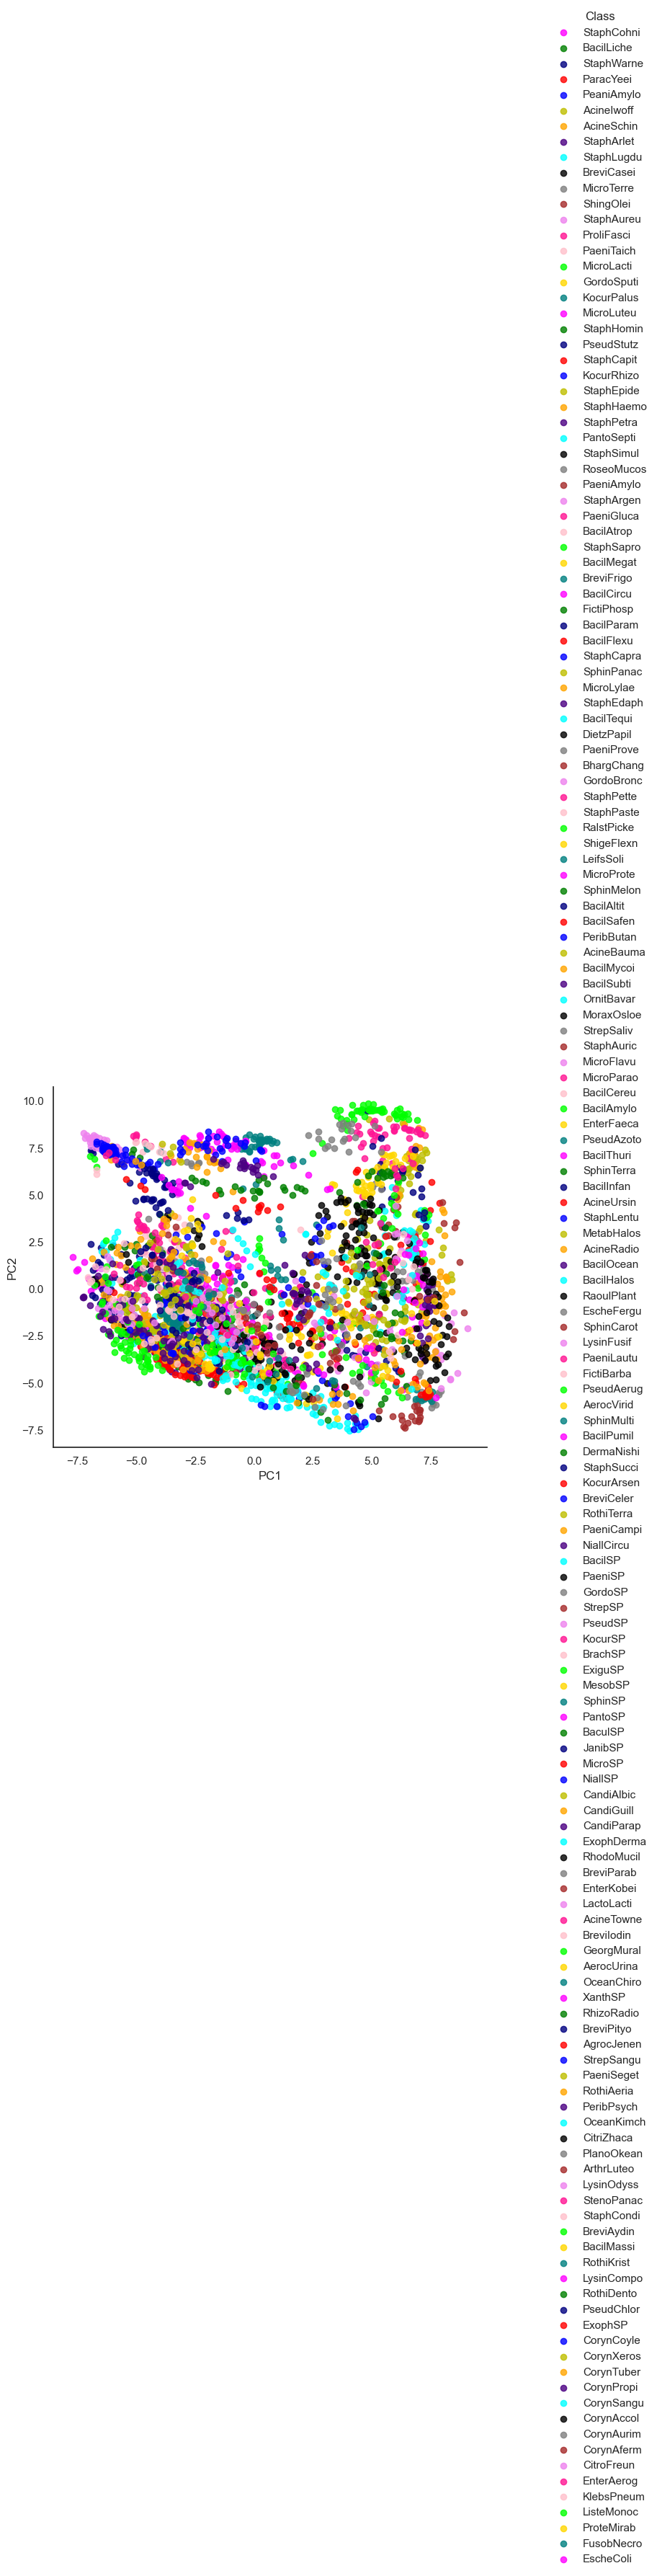

In [7]:
# PCA
sns.set_context("notebook")
sns.set_style("white")
from sklearn.decomposition import PCA
pca = PCA(n_components=3) #keep first 3 components
X_2D = pca.fit(Data_n_log).transform(Data_n_log)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3'])

# label,y= np.unique(file['Label'],return_inverse = True)
# label=file['Label']
colors = ['green','red']
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo', 'cyan', 'black','grey' , 'brown', 'violet', 'deeppink', 'pink', 'lime', 'gold', 'teal']
# lw = 1

PCA_data=tmp_train.copy()
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]


sns.lmplot("PC1", "PC2", hue='Class', data=PCA_data, palette=colors,fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)

#save it
# plt.savefig('D:/BOX/Box Sync/RA/data/IMAGING/LD_REIMS/from Vince/cambridge multiple sclerosis/for Luca/PCA_pos.eps', format='eps')

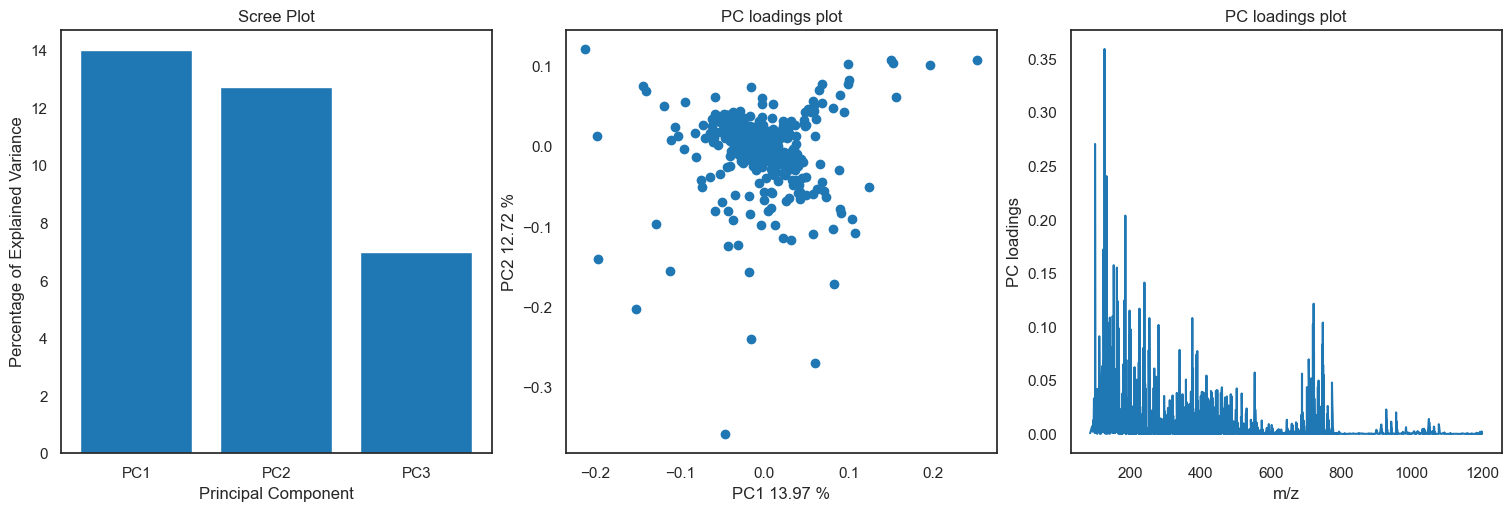

In [8]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

fig,axs = plt.subplots(ncols=3,constrained_layout=True,figsize=(15,5))

axs[0].bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
axs[0].set_ylabel('Percentage of Explained Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_title('Scree Plot')

axs[1].scatter(loadings['PC1'],loadings['PC2'])
axs[1].set_title('PC loadings plot')
axs[1].set_xlabel('PC1 %0.2f %%' % (pca.explained_variance_ratio_[0] * 100))
axs[1].set_ylabel('PC2 %0.2f %%' % (pca.explained_variance_ratio_[1] * 100))

axs[2].plot(mz,loadings['PC2'].abs())
# axs[2].plot(mz,loadings['PC3'])
axs[2].set_title('PC loadings plot')
axs[2].set_xlabel('m/z')
axs[2].set_ylabel('PC loadings');


## 3D PCA (need to install plotly for this to work!)

In [9]:
import plotly.express as px

fig = px.scatter_3d(PCA_data, x='PC1', y='PC2', z='PC3',
              color='Class')
fig.show()
#ax.scatter3D(xdata, ydata, zdata, c=file['Label'], label=file['Label']);
#fig = plt.gcf()
#fig.set_size_inches(12,6)

## *Feature selection using PCA (only if you have clear linear separation within a component)

In [71]:
# PC=loadings['PC3']
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project B/mz.txt', mz,delimiter=',')
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project b/pc.txt', PC,delimiter=',') #for me to save the components

# sorted_loading_values = PC.abs().sort_values(ascending=False)
# # sorted_loading_values
# top_30_mz = sorted_loading_values[0:100].index
# top_30_mz
# PCA_features=mz[top_30_mz]
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project E/features_PCA_APCvsKRAS.txt', PCA_features,delimiter=',')

# Classification models

In [12]:
# get group sizes to be used for cost sensitivity if biased
column = tmp_train['Class']

labelnames = set(column)
labelnames = list(labelnames)

w = np.zeros(len(labelnames))
for i in range(0,len(labelnames)):
    group=tmp_train[column== labelnames[i]]
#     group=file_resample[column== labelnames[i]]
    w[i]=(len(group))
    print('group' + str(i) + ' sampe size: '+str(w[i])+'\n')

print('ratio: '+str(w/max(w)))
weights = {labelnames[0]:1.0, labelnames[1]:w[0]/w[1]}

labelnames

group0 sampe size: 20.0

group1 sampe size: 12.0

group2 sampe size: 14.0

group3 sampe size: 9.0

group4 sampe size: 12.0

group5 sampe size: 18.0

group6 sampe size: 27.0

group7 sampe size: 14.0

group8 sampe size: 10.0

group9 sampe size: 18.0

group10 sampe size: 35.0

group11 sampe size: 47.0

group12 sampe size: 9.0

group13 sampe size: 11.0

group14 sampe size: 21.0

group15 sampe size: 73.0

group16 sampe size: 53.0

group17 sampe size: 26.0

group18 sampe size: 30.0

group19 sampe size: 36.0

group20 sampe size: 15.0

group21 sampe size: 9.0

group22 sampe size: 17.0

group23 sampe size: 29.0

group24 sampe size: 73.0

group25 sampe size: 48.0

group26 sampe size: 55.0

group27 sampe size: 9.0

group28 sampe size: 45.0

group29 sampe size: 12.0

group30 sampe size: 77.0

group31 sampe size: 9.0

group32 sampe size: 9.0

group33 sampe size: 11.0

group34 sampe size: 12.0

group35 sampe size: 18.0

group36 sampe size: 45.0

group37 sampe size: 9.0

group38 sampe size: 15.0

gro

['ExophDerma',
 'SphinSP',
 'StaphSucci',
 'EnterAerog',
 'PaeniLautu',
 'CorynPropi',
 'ParacYeei',
 'BreviCasei',
 'SphinCarot',
 'PseudAerug',
 'StaphEdaph',
 'RhodoMucil',
 'FusobNecro',
 'RaoulPlant',
 'DietzPapil',
 'MoraxOsloe',
 'AcineIwoff',
 'BacilCereu',
 'BacilMegat',
 'StaphCohni',
 'AcineUrsin',
 'PaeniSeget',
 'SphinMelon',
 'BacilAltit',
 'KocurRhizo',
 'BacilAmylo',
 'StaphAureu',
 'CorynAccol',
 'PaeniTaich',
 'KocurArsen',
 'BreviFrigo',
 'RothiKrist',
 'PeribPsych',
 'EnterKobei',
 'SphinPanac',
 'StrepSP',
 'PaeniGluca',
 'AgrocJenen',
 'CorynSangu',
 'LactoLacti',
 'StaphHaemo',
 'MicroTerre',
 'BacilParam',
 'NiallSP',
 'PaeniProve',
 'MicroLacti',
 'StaphPetra',
 'GordoSputi',
 'BhargChang',
 'BaculSP',
 'CorynAurim',
 'ProteMirab',
 'BacilTequi',
 'StaphWarne',
 'StrepSaliv',
 'BacilFlexu',
 'RhizoRadio',
 'BreviIodin',
 'StaphHomin',
 'PeaniAmylo',
 'OrnitBavar',
 'AcineSchin',
 'MesobSP',
 'LeifsSoli',
 'MicroLuteu',
 'CorynXeros',
 'OceanChiro',
 'StaphPette

## Train models with CV
## you can select the classifier ('method'), the cross-validation strategy ('cvsplit', ATM only LOGO or stratified K-fold) and implement a cost-sensitive approach (input 'weights')

## method available = 'LR'(Logistic Regression), 'LDA'(Liner Discriminant Analysis), 'KNN'(k-Nearest Neighbours), 'CART'(Decision Trees), 'NB'(Naiive Bayesian), 'SVM'(Support Vector Machine), 'RF'(Random Forest)

## CV strategies available = 'loo' (leave-one-group-out as specified by 'group' argument), 'kfold' (stratified, default k=10)

In [13]:
results = train_cv (Data_n_log, method='SVM', cvsplit='kfold', 
                    label=column.tolist(), group=tmp_train['Class'], weights = weights)

C:\Users\tr518\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:676: UserWarning:

The least populated class in y has only 6 members, which is less than n_splits=10.



Method SVC(class_weight={'ExophDerma': 1.0, 'SphinSP': 1.6666666666666667},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 185.80574584007263 seconds


## *Visualise CV splitting behaviour (for k-fold mostly)

C:\Users\tr518\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:676: UserWarning:

The least populated class in y has only 6 members, which is less than n_splits=10.



<AxesSubplot:title={'center':'StratifiedKFold'}, xlabel='Sample index', ylabel='CV iteration'>

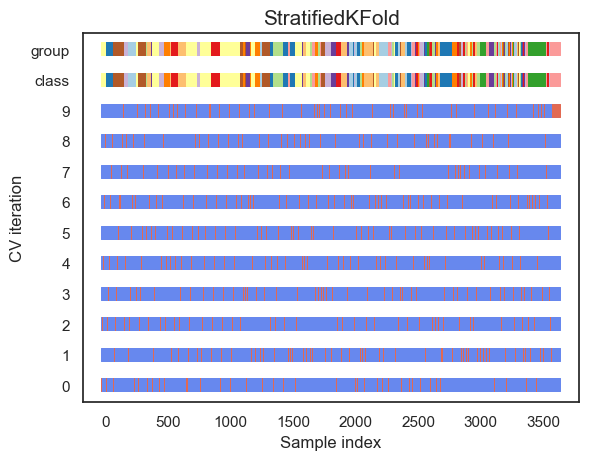

In [14]:
sns.set_context("notebook")
cvsplit = StratifiedKFold(n_splits=10)
old_label = tmp_train['Class'].copy()
old_group = tmp_train['Class'].copy()
plot_cv(cvsplit, Data_n_log, old_label, old_group, 10, lw=10)

## Model(s) evaluation - confusion matrix & ROC analysis

## if you want CM in sample numbers then just take away the 'normalize = true' during calculation

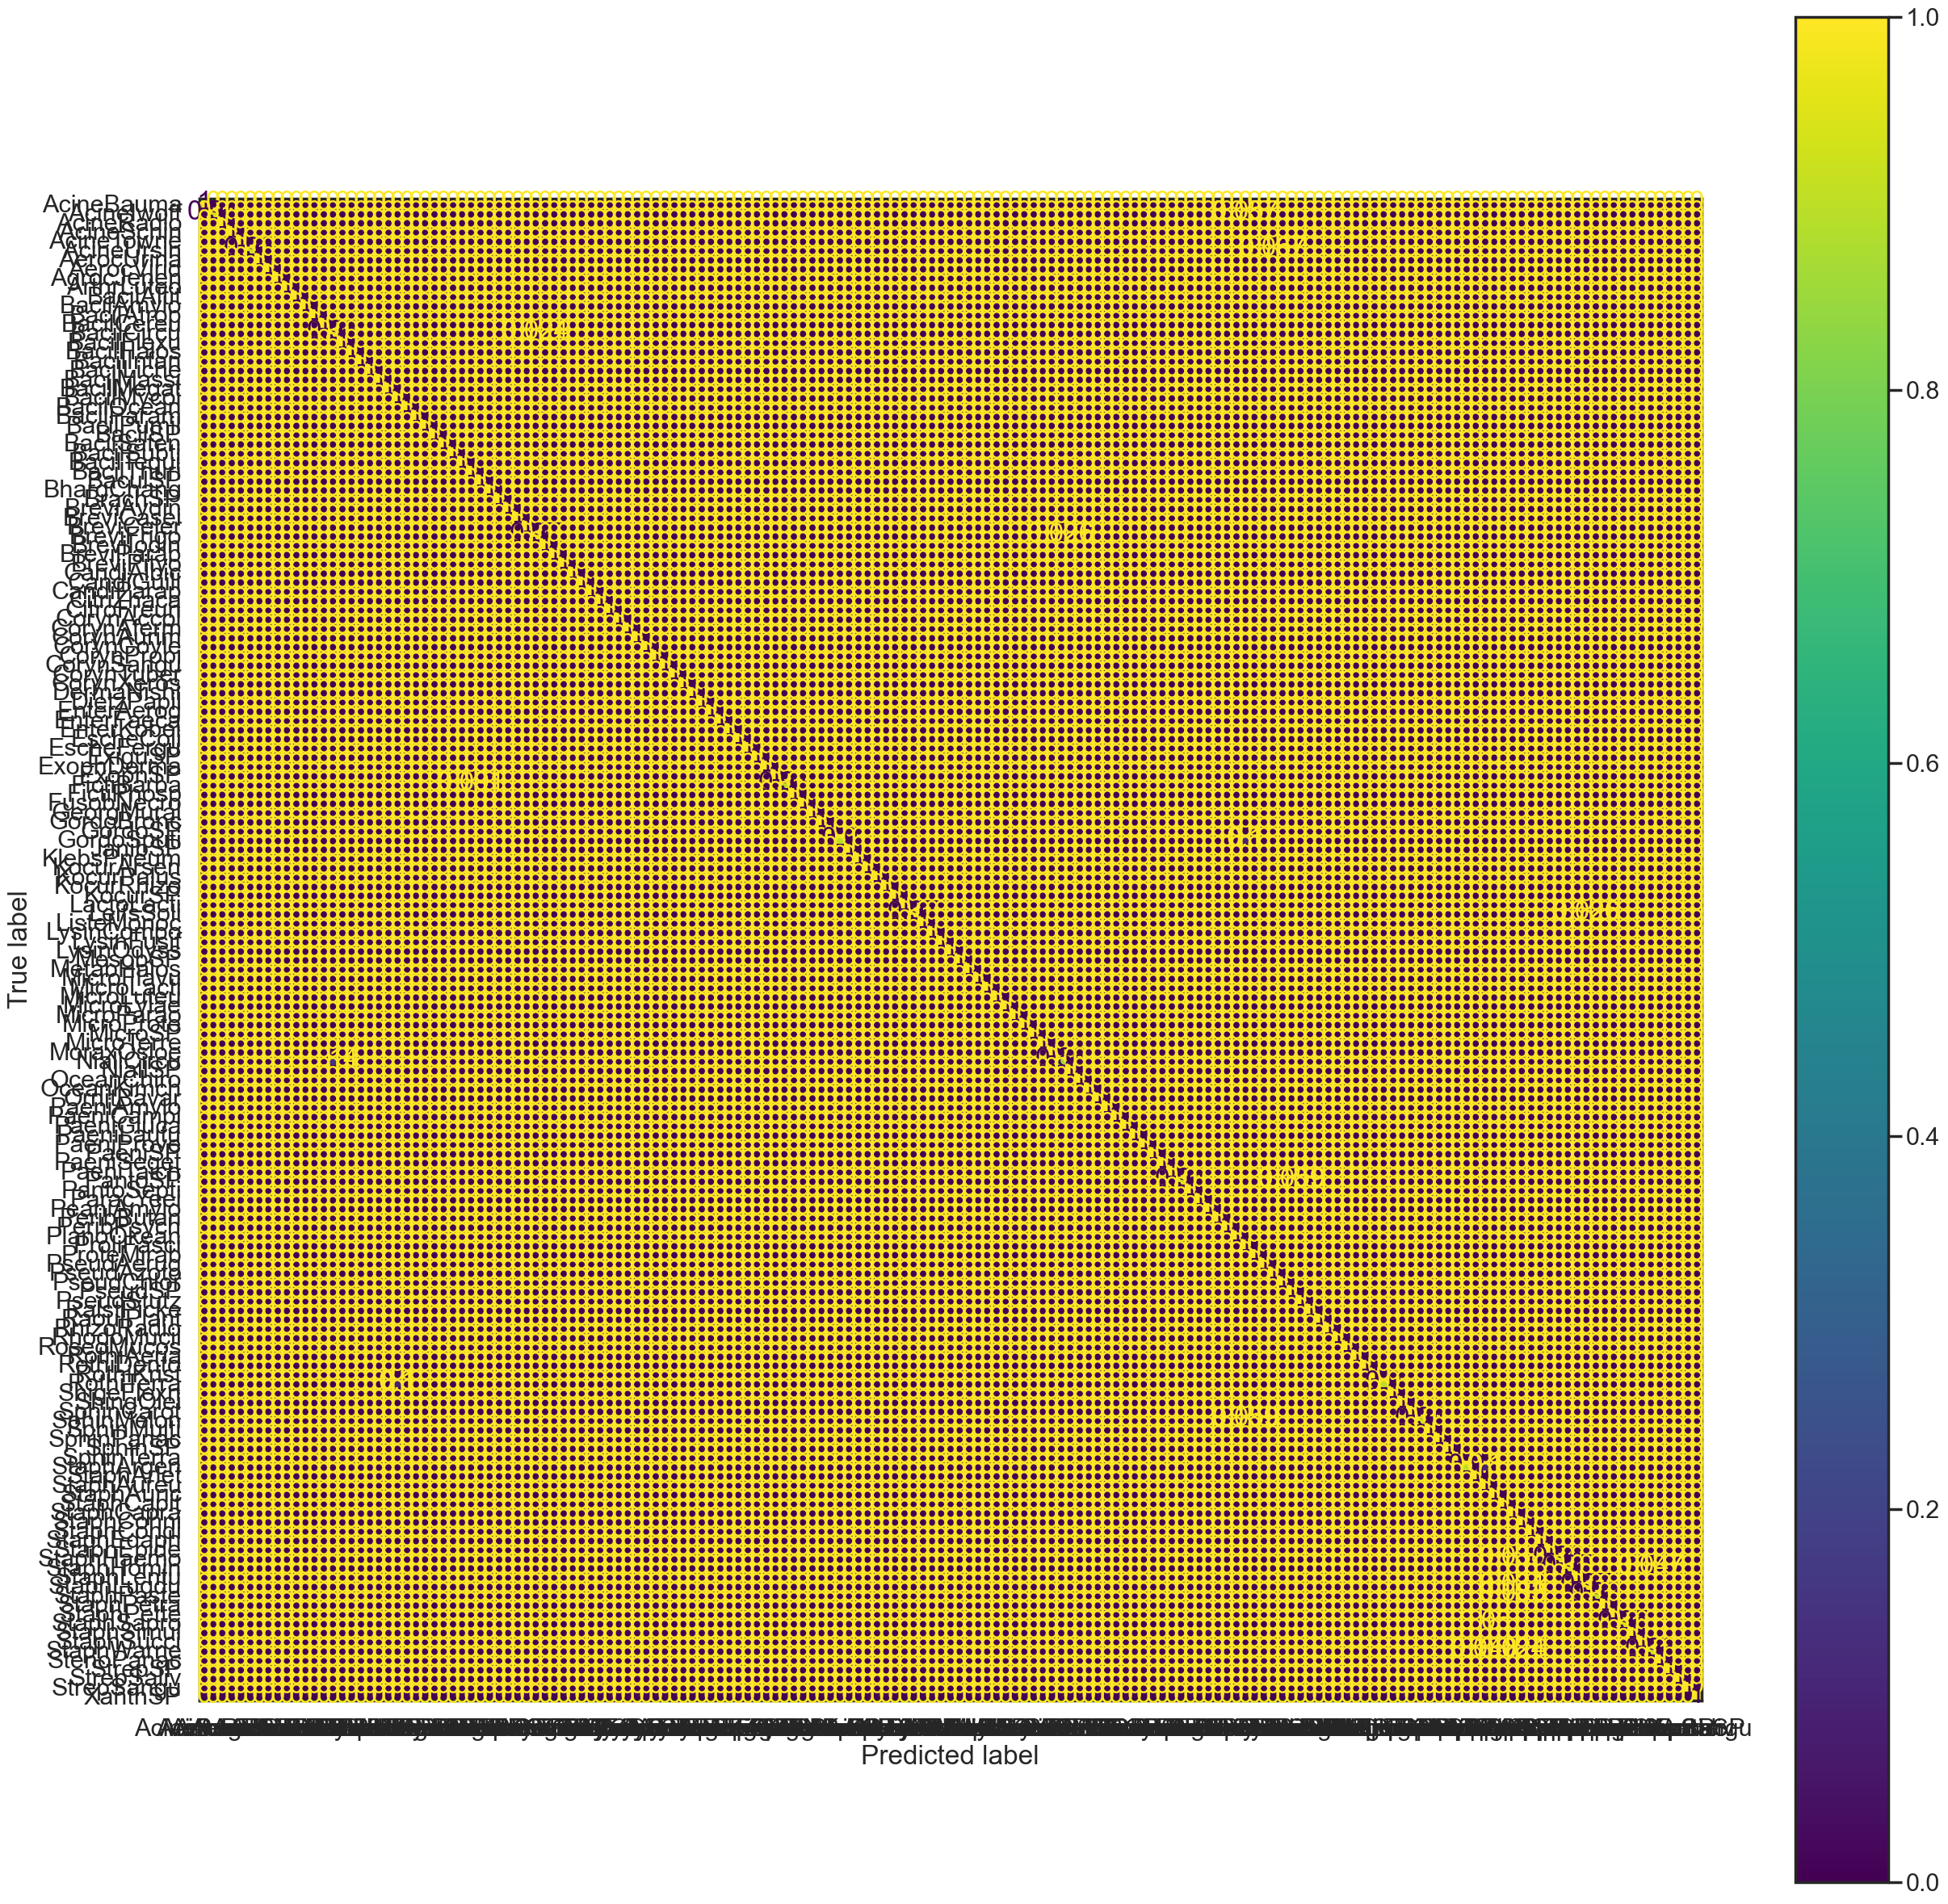

In [15]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.set_context("poster")
classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [28]:
performance = calculate_FPASS (CM,cm_label)
performance
print(performance)
pd.options.display.max_rows = 4000



          class  accuracy sensitivity specificity precision        F1
0    AcineBauma       1.0         1.0         1.0       1.0       1.0
1    AcineIwoff  0.971698    0.943396         1.0       1.0  0.970874
2    AcineRadio       1.0         1.0         1.0       1.0       1.0
3    AcineSchin       1.0         1.0         1.0       1.0       1.0
4    AcineTowne       1.0         1.0         1.0       1.0       1.0
5    AcineUrsin  0.966667    0.933333         1.0       1.0  0.965517
6    AerocUrina       1.0         1.0         1.0       1.0       1.0
7    AerocVirid       1.0         1.0         1.0       1.0       1.0
8    AgrocJenen       1.0         1.0         1.0       1.0       1.0
9    ArthrLuteo       1.0         1.0         1.0       1.0       1.0
10   BacilAltit       1.0         1.0         1.0       1.0       1.0
11   BacilAmylo       1.0         1.0         1.0       1.0       1.0
12   BacilAtrop       1.0         1.0         1.0       1.0       1.0
13   BacilCereu     

## ROC analysis - this will plot the 'macro average' if you have more than 2 classes, you can plot for a particular class by e.g. defining the input argument 'plotwhich=2' (so plot ROC for class 2); and in the case of k-fold, it currently plots a randomly selected 'fold' (i.e. the performance may change everytime you plot); you can also save the predicted probabilities by defining 'saveprobs=True'
## to-do: plot the average of k-fold

C:\Users\tr518\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:676: UserWarning:

The least populated class in y has only 6 members, which is less than n_splits=10.

C:\Users\tr518\AppData\Local\Temp\ipykernel_33144\936550576.py:54: VisibleDeprecationWarning:

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.

C:\Users\tr518\AppData\Local\Temp\ipykernel_33144\936550576.py:55: VisibleDeprecationWarning:

Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.

C:\Users\tr518\Anaconda3\lib\site-packages\sklearn\metrics\_ranking.py:999: UndefinedMetricWarning:

No positive samples in y_true, true positive valu

there are 163 classes


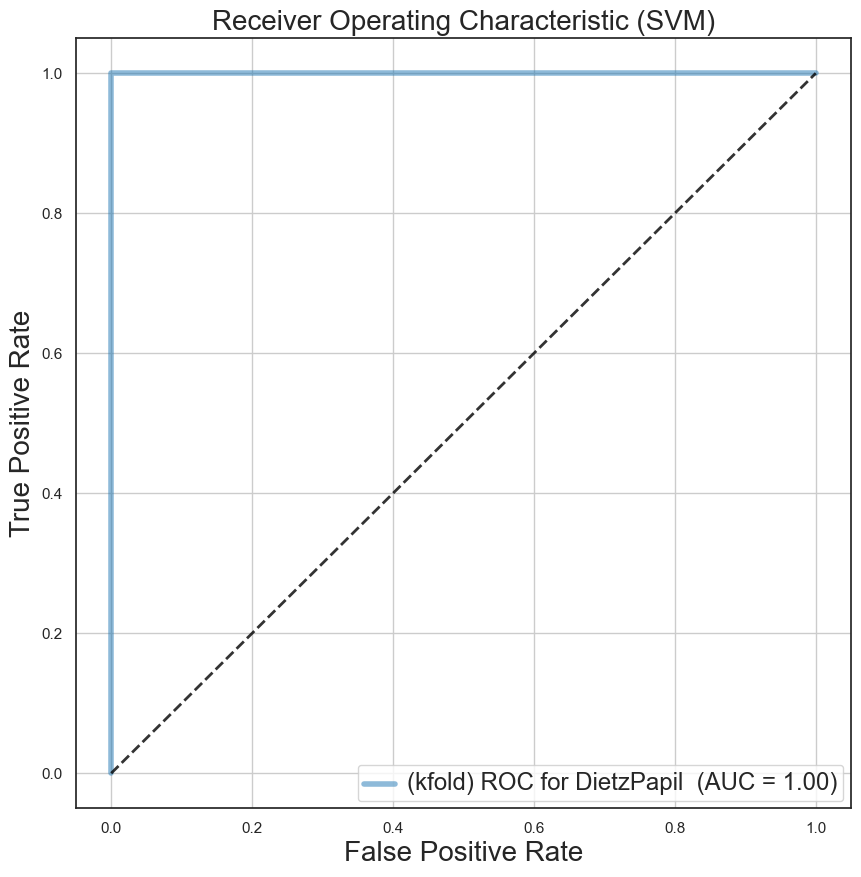

In [29]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from random import randrange

[model, all_probs, FPRs, TPRs, AUCs] = do_ROC (Data_n_log, tmp_train['Class'].values, method='SVM', 
                                        cvsplit='kfold', plotwhich = 54, saveprobs = True)

# Save trained model & test new data

## the trained model will be saved to a folder called 'Trained_models', you can name the model to be anything (e.g. 'XXX.sav')

In [41]:
model_tosave = model
model_tosave.fit(Data_n_log, column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/LARGE_MODEL_REF_SNV_AVF_ONOFF_TIC_LOG.sav', 'wb'))

SVC(class_weight={'ExophDerma': 1.0, 'SphinSP': 1.6666666666666667},
    decision_function_shape='ovo', kernel='linear', probability=True)
saved


In [48]:
# load test data from file

tmp_test, Data_test, mz_test = load_data('D:/_Peak_picking/_FINAL_LARGE MODEL BUILDING/Results_G_SP/matrix_for_postprocessing_val.csv', features = mz)
Data_test_n = data_norm(Data_test, method='tic')
Data_test_n_log = data_norm(Data_test_n, method='log')
Data_test_n_log.shape

data already has the same spectral variables


(669, 2265)

In [49]:
model_name = 'Trained_models/LARGE_MODEL_REF_SNV_AVF_ONOFF_TIC_LOG.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['Class'].tolist()
test_results = loaded_model.predict(Data_test_n_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
#disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)



<Figure size 3000x3000 with 0 Axes>

In [50]:
performance = calculate_FPASS (CM,cm_label)
performance
print(performance)
pd.options.display.max_rows = 4000

C:\Users\tr518\AppData\Local\Temp\ipykernel_33144\2551593479.py:12: RuntimeWarning:

invalid value encountered in double_scalars



IndexError: index 50 is out of bounds for axis 0 with size 50

## the CM alone can be 'deceiving' as most trained models are probabilistic and give the probabilities of a sample belonging to a certain class. If an inappropriate threshold was chosen (i.e. P>=threshold to be predicted to be a certain class), then the performance may appear to worsen when compared to CV results. To understand where this threshold should be, also check the ROC curves for the test data

there are 15 classes


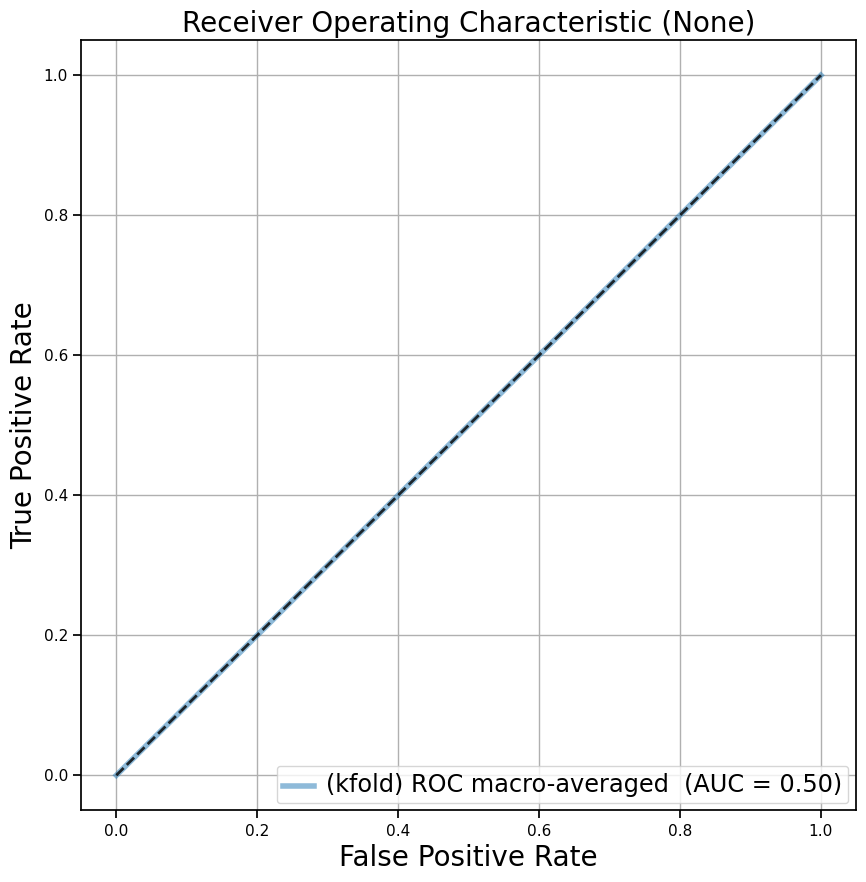

In [16]:
[model, all_probs, FPRs, TPRs, AUCs] = do_ROC (Data_test_n_log, tmp_test['Class'].values, saved_model = loaded_model,
        plotwhich = 'macro', saveprobs = True)

# Feature selection methods

## Feature selection with LR - there are 3 main methods:

## 1. Using the relative importance of LR coefficients obtained during model training; if you have more than 2 classes, then remember that LR CANNOT do true multi-class classification and instead it will do 'one-vs-rest' for as many times as you have classes. The output features are automatically saved (unless you turn it off with 'save = False') and you can define the number features (e.g. num_features = 50)

In [22]:
LR_features, importance = LR_importance(Data_n_log, tmp_train['Class'], num_features = 10, save=True)
LR_features

,0,1,2,3,4,5,6,7,8,9,...,95,96,97,98,99,100,101,102,103,104
0,693.4655,694.4677,747.5138,281.2418,241.2107,745.5116,707.4771,673.4768,671.4600,279.2320,...,716.5182,255.2270,703.5060,227.1945,679.4494,693.4655,694.4677,749.5187,662.4701,735.5089
1,679.4494,750.5255,695.4704,707.4771,763.5375,749.5187,693.4655,735.5089,721.4941,694.4677,...,747.5138,673.4768,745.5116,377.0815,671.4600,217.0444,697.4782,594.2955,219.0407,311.1635
2,697.4782,725.5046,279.2320,716.5182,723.4990,699.4935,835.5297,685.4754,740.5160,698.4795,...,693.4655,377.0815,716.5182,217.0444,694.4677,693.4655,694.4677,688.4898,719.4830,747.5138
3,702.5070,679.4494,716.5182,689.4918,695.4704,688.4898,217.0444,377.0815,747.5138,702.5070,...,693.4655,707.4771,721.4941,694.4677,835.5297,281.2418,693.5211,695.5364,679.4494,673.4768
4,693.4655,694.4677,835.5297,281.2418,241.2107,693.5211,695.5364,679.4494,695.4704,673.4768,...,694.4677,279.2320,299.2512,691.4980,679.4494,693.4655,694.4677,281.2418,693.5211,279.2320
5,299.2512,255.2270,679.4494,691.4980,695.4704,693.5211,299.2512,311.1635,691.4980,377.0815,...,733.4981,702.5070,217.0444,377.0815,734.4995,761.5230,267.2274,703.5060,192.9836,219.0407
6,702.5070,703.5060,733.4981,215.1570,734.4995,169.1511,659.4655,267.2274,718.5213,716.5182,...,694.4677,733.4981,267.2274,730.5283,227.1945,693.4655,749.5187,217.0444,694.4677,707.4771
7,750.5255,679.4494,763.5375,735.5089,377.0815,749.5187,735.5089,693.4655,750.5255,679.4494,...,679.4494,695.4704,675.4810,899.5424,665.4306,680.4506,676.4810,217.0444,619.4294,693.8047
8,747.5138,745.5116,217.0444,716.5182,717.5162,377.0815,688.4898,715.5026,746.5075,748.5166,...,750.5255,735.5089,722.4965,714.5045,748.5166,716.5182,747.5138,693.4655,745.5116,714.5045
9,694.4677,748.5166,281.2418,746.5075,717.5162,702.5070,227.1945,192.9836,267.2274,716.5182,...,778.5650,433.2567,749.4091,187.0994,694.4677,405.2241,523.2834,512.1671,927.5712,512.2469


## *Feature selection for LR using log-likelihood test, only for binary classification!

In [39]:
from sklearn.metrics import log_loss
from scipy.stats import chi2

LR_features2 = LR_loglike(Data_n_log, tmp_train_r['Class'], threshold = 2.0, save = False)
LR_features2

NameError: name 'tmp_train_r' is not defined

## Feature selection using RFE (Recursive Feature Elimination)
## standard RFE produces any defined number of features

In [39]:
# Here I chose 30 features

from sklearn.feature_selection import RFE
print(model)

RFE_features = RFE_select(Data_log, tmp_train['Class'],n_features = 50)
RFE_features

SVC(class_weight={'MLUT': 1.0, 'PAER': 0.96}, decision_function_shape='ovo',
    kernel='linear', probability=True)

that took 17.87394952774048 seconds


,0
0,164.0396
1,187.0985
2,192.9836
3,197.1194
4,217.0445
5,217.0991
6,225.0820
7,227.1951
8,238.0736
9,241.1110


## if you are unsure how many features are necessary, use RFECV below as it will use a CV-based 'grid search' to also determine the optimal numer of features (5-fold by default), this is much slower!

In [40]:
# RFECV - use CV to determine & select best number of features

from sklearn.feature_selection import RFECV
print(model)

RFECV_features = RFECV_select(Data_log, tmp_train['Class'])
RFECV_features

SVC(class_weight={'MLUT': 1.0, 'PAER': 0.96}, decision_function_shape='ovo',
    kernel='linear', probability=True)

that took 103.22072219848633 seconds


,0
0,152.9894
1,164.0396
2,181.0859
3,187.0985
4,192.9836
...,...
79,745.5170
80,746.5168
81,749.5200
82,750.5204


## Feature selection with LASSO (only for binary classification!)

In [41]:
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

lasso_features = LASSO_select(Data_log,tmp_train_r['Label'])
lasso_features

,0
0,61.000751
1,115.007980
2,125.041191
3,128.191345
4,130.058685
...,...
199,1214.768066
200,1386.114380
201,1427.137085
202,1470.162231


## Combine different FS approaches to generate a list of (overlapping) features & generate new data matrix with only these features

In [50]:
allfeatures = match_features([RFECV_features])
allfeatures

Data_train_s=np.zeros((len(Data_train),len(allfeatures)))
for n in range (0,len(allfeatures)):
    index= np.argmin(abs(mz-allfeatures[n]))
    Data_train_s[:,n]=Data_train.iloc[:,index]
    
output = pd.DataFrame(data=Data_train_s)
output['Class'] = tmp_train['Class']
output['Sample'] = tmp_train['Sample']
i = 0
for mz_i in allfeatures:
    mz_i = float(mz_i)
    output = output.rename(columns={i: (mz_i)})
    i = i+1
output

,152.9894,164.0396,181.0859,187.0985,192.9836,197.1194,199.0653,199.1642,217.0445,217.0991,...,735.5053,736.5034,742.5356,745.517,746.5168,749.52,750.5204,761.523,Class,Sample
0,2181.548934,2162.216396,0.000000,0.000000,55116.386450,12805.861080,5108.935329,2433.282678,27488.103760,2393.032521,...,3418.703681,0.000000,2429.239129,2475.603287,0.000000,2420.357751,0.0,6689.868893,PMIR,AZ008_0000571_20190227
1,1929.932893,2664.934622,0.000000,0.000000,73405.358220,10468.850750,6080.701660,1752.982402,36110.795730,2664.519311,...,2749.764535,0.000000,2819.519489,3122.440031,0.000000,2679.681905,0.0,5555.267599,PMIR,AZ008_0000581_20190226
2,6070.902503,1480.915172,2667.487653,0.000000,64264.295330,7612.574726,4387.715945,2095.519453,19729.630280,1809.728908,...,11891.204700,2675.613936,5513.413544,8496.344414,3664.952262,8517.171126,0.0,26619.805050,PMIR,AZ008_0000599_20190225
3,1529.152599,2038.042536,0.000000,0.000000,42506.922010,7788.108753,4756.432860,1794.174494,35936.911830,0.000000,...,1953.878607,0.000000,2734.857697,2423.009403,0.000000,2042.927665,0.0,4014.306475,PMIR,AZ008_0000606_20190226
4,2509.743415,1690.000296,0.000000,0.000000,53335.908490,7350.402266,3237.732332,4293.672410,26657.673540,2088.656094,...,3393.901422,0.000000,2555.890852,2453.362559,0.000000,2494.944162,0.0,7183.920217,PMIR,AZ008_0000611_20190227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,5261.046864,0.000000,4269.510051,6394.960750,4948.521150,3505.568006,3952.454171,0.000000,4076.592344,3842.735302,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01346_20190225
370,2987.668497,0.000000,4135.398936,23799.591390,4498.755285,4875.943389,5001.765082,0.000000,5471.438745,4558.353282,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01347_20190225
371,6524.163805,0.000000,3400.111209,20972.308100,5763.999591,3362.100391,3953.970632,0.000000,2407.424565,3946.413578,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01371_20190226
372,5314.051873,0.000000,3848.785339,7383.235365,9265.996249,3508.494955,3712.942761,0.000000,6983.144491,3394.741124,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01375_20190227


## Save new data matrix

In [42]:
output.to_csv (r'data_select_class_filt1_log_svn.csv', index = False, header=True)
output

,152.9894,164.0396,181.0859,187.0985,192.9836,197.1194,199.0653,199.1642,217.0445,217.0991,...,735.5053,736.5034,742.5356,745.517,746.5168,749.52,750.5204,761.523,Class,Sample
0,2181.548934,2162.216396,0.000000,0.000000,55116.386450,12805.861080,5108.935329,2433.282678,27488.103760,2393.032521,...,3418.703681,0.000000,2429.239129,2475.603287,0.000000,2420.357751,0.0,6689.868893,PMIR,AZ008_0000571_20190227
1,1929.932893,2664.934622,0.000000,0.000000,73405.358220,10468.850750,6080.701660,1752.982402,36110.795730,2664.519311,...,2749.764535,0.000000,2819.519489,3122.440031,0.000000,2679.681905,0.0,5555.267599,PMIR,AZ008_0000581_20190226
2,6070.902503,1480.915172,2667.487653,0.000000,64264.295330,7612.574726,4387.715945,2095.519453,19729.630280,1809.728908,...,11891.204700,2675.613936,5513.413544,8496.344414,3664.952262,8517.171126,0.0,26619.805050,PMIR,AZ008_0000599_20190225
3,1529.152599,2038.042536,0.000000,0.000000,42506.922010,7788.108753,4756.432860,1794.174494,35936.911830,0.000000,...,1953.878607,0.000000,2734.857697,2423.009403,0.000000,2042.927665,0.0,4014.306475,PMIR,AZ008_0000606_20190226
4,2509.743415,1690.000296,0.000000,0.000000,53335.908490,7350.402266,3237.732332,4293.672410,26657.673540,2088.656094,...,3393.901422,0.000000,2555.890852,2453.362559,0.000000,2494.944162,0.0,7183.920217,PMIR,AZ008_0000611_20190227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,5261.046864,0.000000,4269.510051,6394.960750,4948.521150,3505.568006,3952.454171,0.000000,4076.592344,3842.735302,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01346_20190225
370,2987.668497,0.000000,4135.398936,23799.591390,4498.755285,4875.943389,5001.765082,0.000000,5471.438745,4558.353282,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01347_20190225
371,6524.163805,0.000000,3400.111209,20972.308100,5763.999591,3362.100391,3953.970632,0.000000,2407.424565,3946.413578,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01371_20190226
372,5314.051873,0.000000,3848.785339,7383.235365,9265.996249,3508.494955,3712.942761,0.000000,6983.144491,3394.741124,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,BSIM,AZ008_AZ01375_20190227


## Train & evaluate new model with only selected features

In [43]:
results = train_cv (data_norm(Data_train_s, method='log'), method='SVM', cvsplit='kfold', 
                    label=column.tolist(), group=output['Class'], weights = weights)

Method SVC(class_weight={'MLUT': 1.0, 'PAER': 0.96}, decision_function_shape='ovo',
    kernel='linear', probability=True) iteration 0 
that took 0.20802783966064453 seconds


,class,accuracy,sensitivity,specificity,precision,F1
0,BSIM,1.0,1.0,1.0,1.0,1.0
1,CALB,1.0,1.0,1.0,1.0,1.0
2,CKOS,0.998571,1.0,0.997143,0.961538,0.980392
3,CPAR,0.998571,1.0,0.997143,0.961538,0.980392
4,CTRO,0.98,0.96,1.0,1.0,0.979592
5,ECOL,1.0,1.0,1.0,1.0,1.0
6,KRHI,0.96,0.92,1.0,1.0,0.958333
7,MLUT,0.997143,1.0,0.994286,0.925926,0.961538
8,MOSL,0.975714,0.96,0.991429,0.888889,0.923077
9,PAER,0.98,0.96,1.0,1.0,0.979592


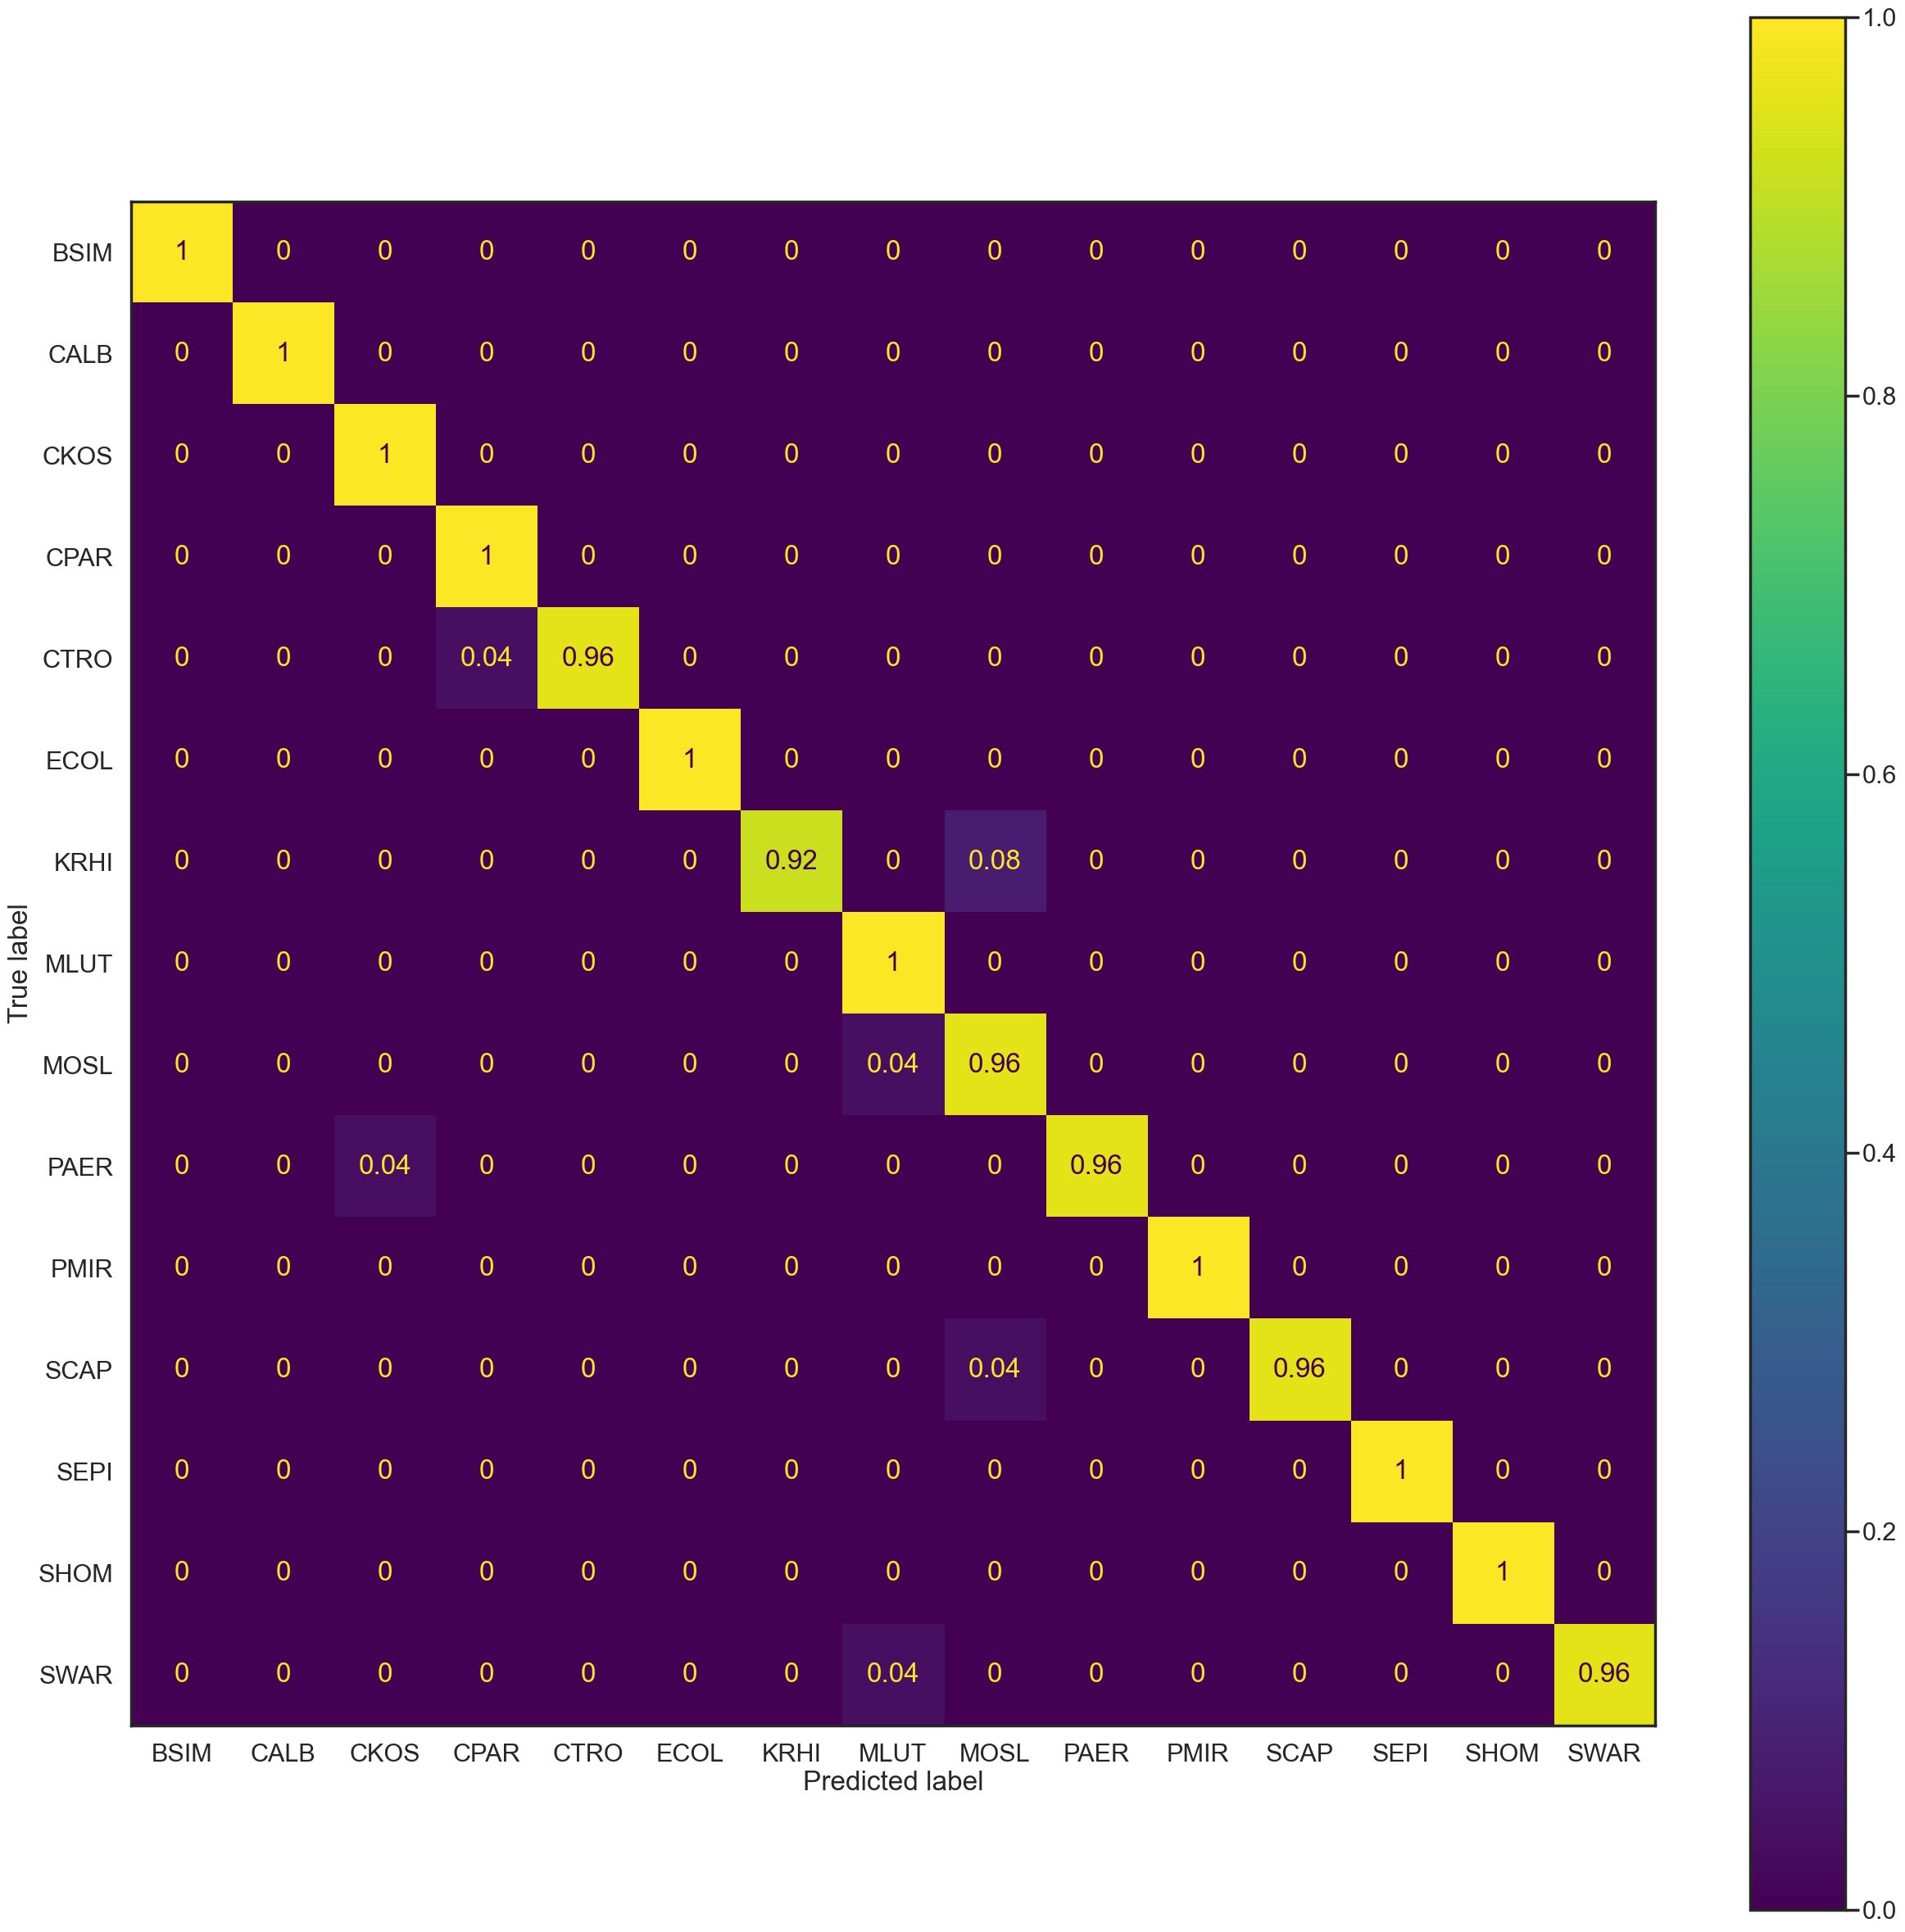

In [44]:
sns.set_context("poster")

classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

performance = calculate_FPASS (CM,cm_label)
performance

## Save new model with only selected features

In [45]:
model_tosave = model
model_tosave.fit(data_norm(Data_train_s, method='log'), column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/SVM_class_fil1_64f_log.sav', 'wb'))

SVC(class_weight={'MLUT': 1.0, 'PAER': 0.96}, decision_function_shape='ovo',
    kernel='linear', probability=True)
saved


## Load data and test with new model

In [46]:
tmp_test, Data_test,mz_test = load_data("matrix_for_postprocessing.val1.csv", features = allfeatures)
# Data_test_n = data_norm(Data_test, method='tic')
Data_test_log = data_norm(Data_test, method='log')
Data_test_log.shape

data already has the same spectral variables


(150, 548)

In [54]:
model_name = 'Trained_models/SVM_onoff_fil1_188f_log.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['Class'].tolist()
test_results = loaded_model.predict(Data_test_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

ValueError: X.shape[1] = 954 should be equal to 188, the number of features at training time

# Feature selection with univariate analysis

## Kruskal-Wallis test (non-parametric for multiple groups)

In [19]:
from bioinfokit import analys, visuz
from scipy import stats

green = labelnames[0]
red = labelnames[1]
green_data=Data_n_log[tmp_train['Class']== green]
green_data = pd.DataFrame(green_data)
red_data=Data_n_log[tmp_train['Class']== red]
red_data = pd.DataFrame(red_data)
print('comparing '+ green+' & '+red)

p_vals_KW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_KW[i]=1
    else:
        dum1=stats.kruskal(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_KW[i]=(dum2)        

comparing PMIR & CTRO


## *Mann-Whitney test (non-parametric binary problem)

## KW test = MW test for a two-way comparison~

In [20]:
p_vals_MW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_MW[i]=1
    else:
        dum1=stats.mannwhitneyu(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_MW[i]=(dum2)

## FDR correction

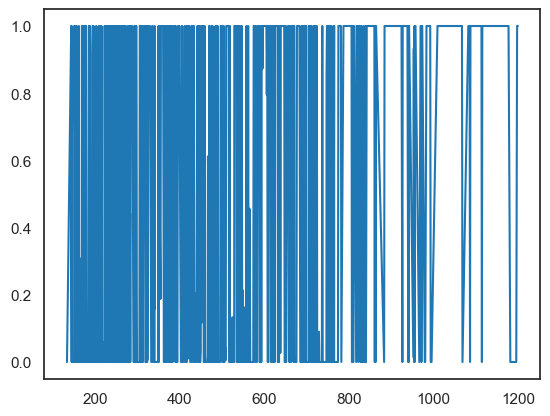

In [21]:
[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method='indep', is_sorted=False)

plt.plot(mz,correct_p)
# p_vals.shape

## *features can be selected based on corrected p-values alone or using volcano plot (below)

In [22]:
p_threshold = 0.05
features = [correct_p <= p_threshold]
features_KW = mz[tuple(features)]
features_KW

array([ 134.0403,  145.0245,  146.0372,  147.0395,  149.0203,  149.0574,
        150.036 ,  151.0337,  153.0558,  155.0749,  156.0601,  158.0454,
        159.0379,  161.035 ,  163.0421,  164.0383,  164.0627,  165.055 ,
        166.0523,  166.0769,  167.0337,  167.0435,  168.0641,  169.0513,
        169.0891,  171.04  ,  172.0435,  173.0367,  173.0488,  174.0414,
        174.0677,  175.0363,  175.0469,  176.043 ,  177.0548,  179.0408,
        179.0766,  180.0692,  181.049 ,  181.0632,  181.0867,  182.047 ,
        183.0606,  183.1049,  184.0606,  185.0555,  186.1162,  187.0364,
        187.0528,  187.0994,  188.0515,  189.0483,  189.0592,  190.0506,
        191.0371,  191.0727,  192.062 ,  192.9836,  193.0551,  193.0823,
        193.9874,  195.0682,  195.102 ,  197.0494,  198.0783,  199.1634,
        200.0544,  200.1328,  201.0587,  202.0593,  203.0608,  203.0729,
        204.06  ,  205.0472,  205.0895,  208.0592,  208.0982,  209.0849,
        210.078 ,  211.0639,  212.094 ,  213.0525, 

## fold changes calculation for volcano plot

C:\Users\tr518\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


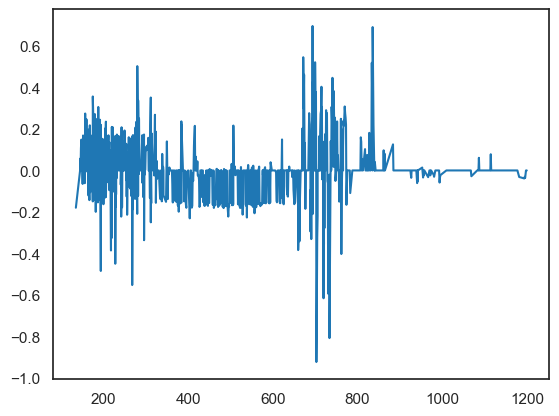

In [23]:
green_mean=np.mean(green_data.iloc[:,:])
green_mean=np.where(green_mean==0, 1, green_mean) 
red_mean=np.mean(red_data.iloc[:,:])
red_mean=np.where(red_mean==0, 1, red_mean) 

fc=green_mean/red_mean
log2fc=np.log2(fc)

plt.plot(mz,log2fc)

## plot and save volcano plot
## working example: https://www.reneshbedre.com/blog/volcano.html

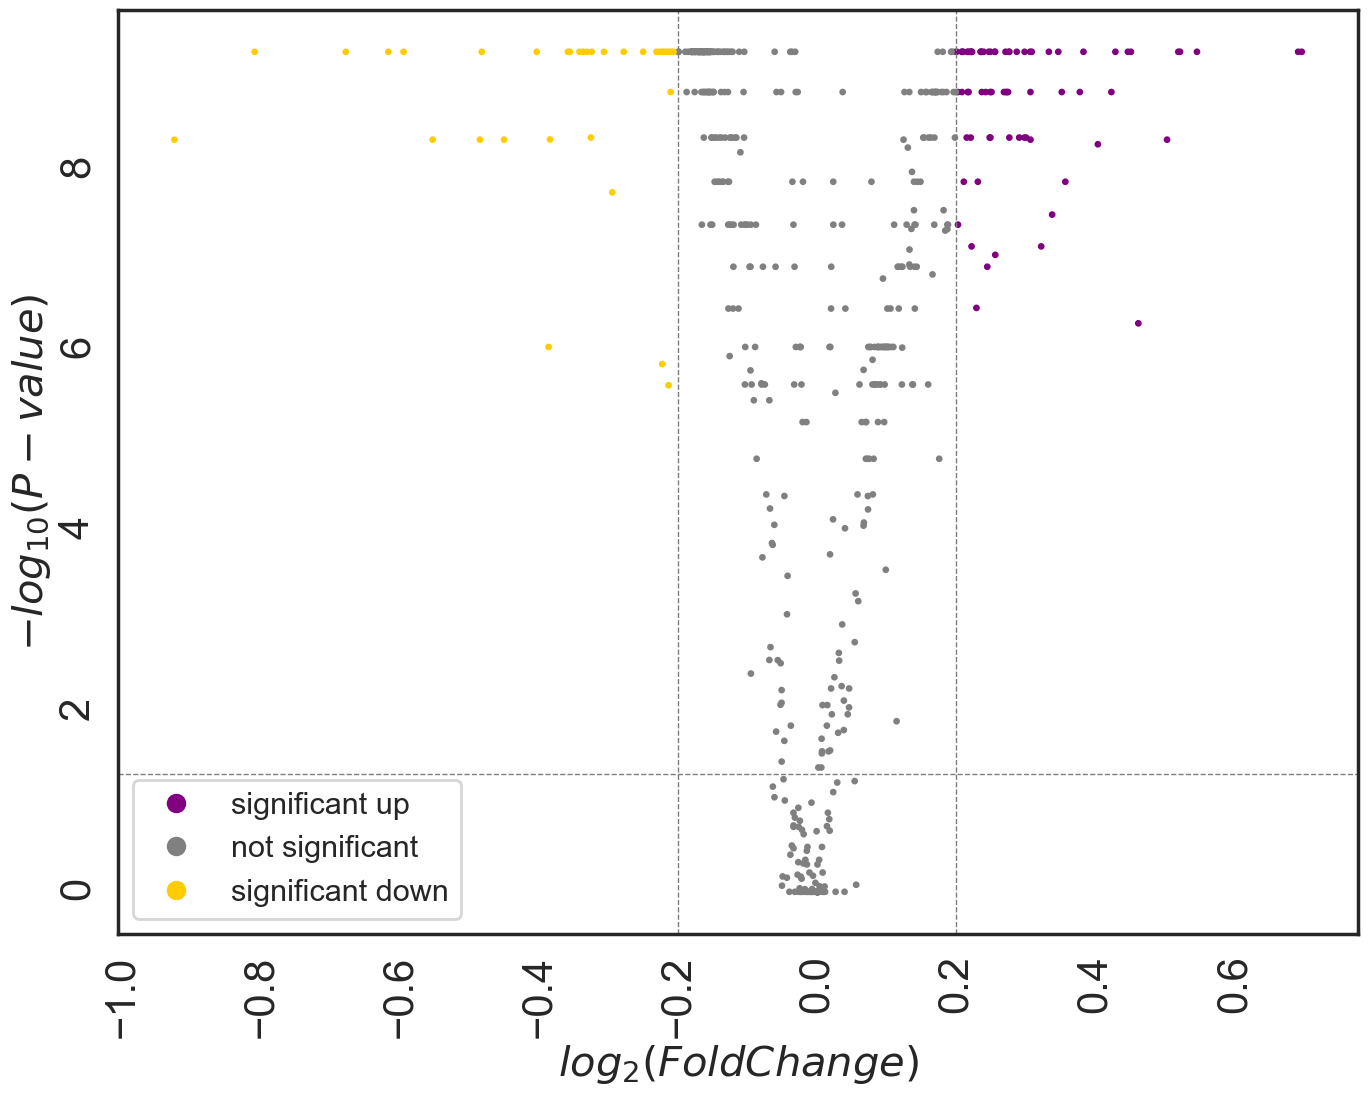

In [27]:
mzlabel=[''] * len(mz)
for i in range(len(mz)):
    mzlabel[i]=str(mz[i])

volcano_data=pd.DataFrame(index=range(0,len(mz)),columns=['pvals','fc','mz'])
volcano_data.iloc[:,0]=correct_p
volcano_data.iloc[:,1]=log2fc
volcano_data.iloc[:,2]=mzlabel
top30=volcano_data['pvals'].sort_values(ascending=True)
top30 = top30[0:30].index
# labels=mz[top30]
labels=np.array2string(mz[top30],separator=',',precision=12)

sns.set_context("poster")
fig = visuz.GeneExpression.volcano(df=volcano_data, lfc='fc', pv='pvals',geneid='mz', dim = [16,12],
                                   lfc_thr=(0.2, 0.2), pv_thr=(0.05, 0.05),
                             genenames=({

}),
color=("purple", "grey", "#FFCC00"), gstyle = 1, gfont = 8.0, plotlegend=True,legendpos='lower left',
                                   axtickfontsize = 30,axlabelfontsize=30, sign_line=True,show=True)

## select features according volcano plot thresholds

In [25]:
p_threshold = 0.05
fc_threshold = 0.1
condition=(volcano_data['pvals'] <= p_threshold) & (abs(volcano_data['fc']) >= fc_threshold)
vol_features=pd.DataFrame(mz[condition])

vol_features
# vol_features.to_csv (r'vol_features.csv', index = False, header=True)

,0
0,134.0403
1,146.0372
2,147.0395
3,151.0337
4,156.0601
...,...
344,835.5297
345,836.5324
346,837.5355
347,838.5461


# Box plotting

## save box plots of selected features to defined path
## syntax: box_plot(list of features, mz, filename, column name to use for labels, save (True or False), savepath)

In [48]:
features_from_file = np.loadtxt('D:/_R_Analysis_Random_forest/AZ008_New_Peakpicking_Val1234_Ref/AZ008_OnOff_average_filtering1/data_select_onoff_filt1_tic_log_svn1.txt')

C:\Users\tr518\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 24.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\tr518\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 32.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\tr518\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\tr518\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 28.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\tr518\Anaconda3\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 29.2% of the points 

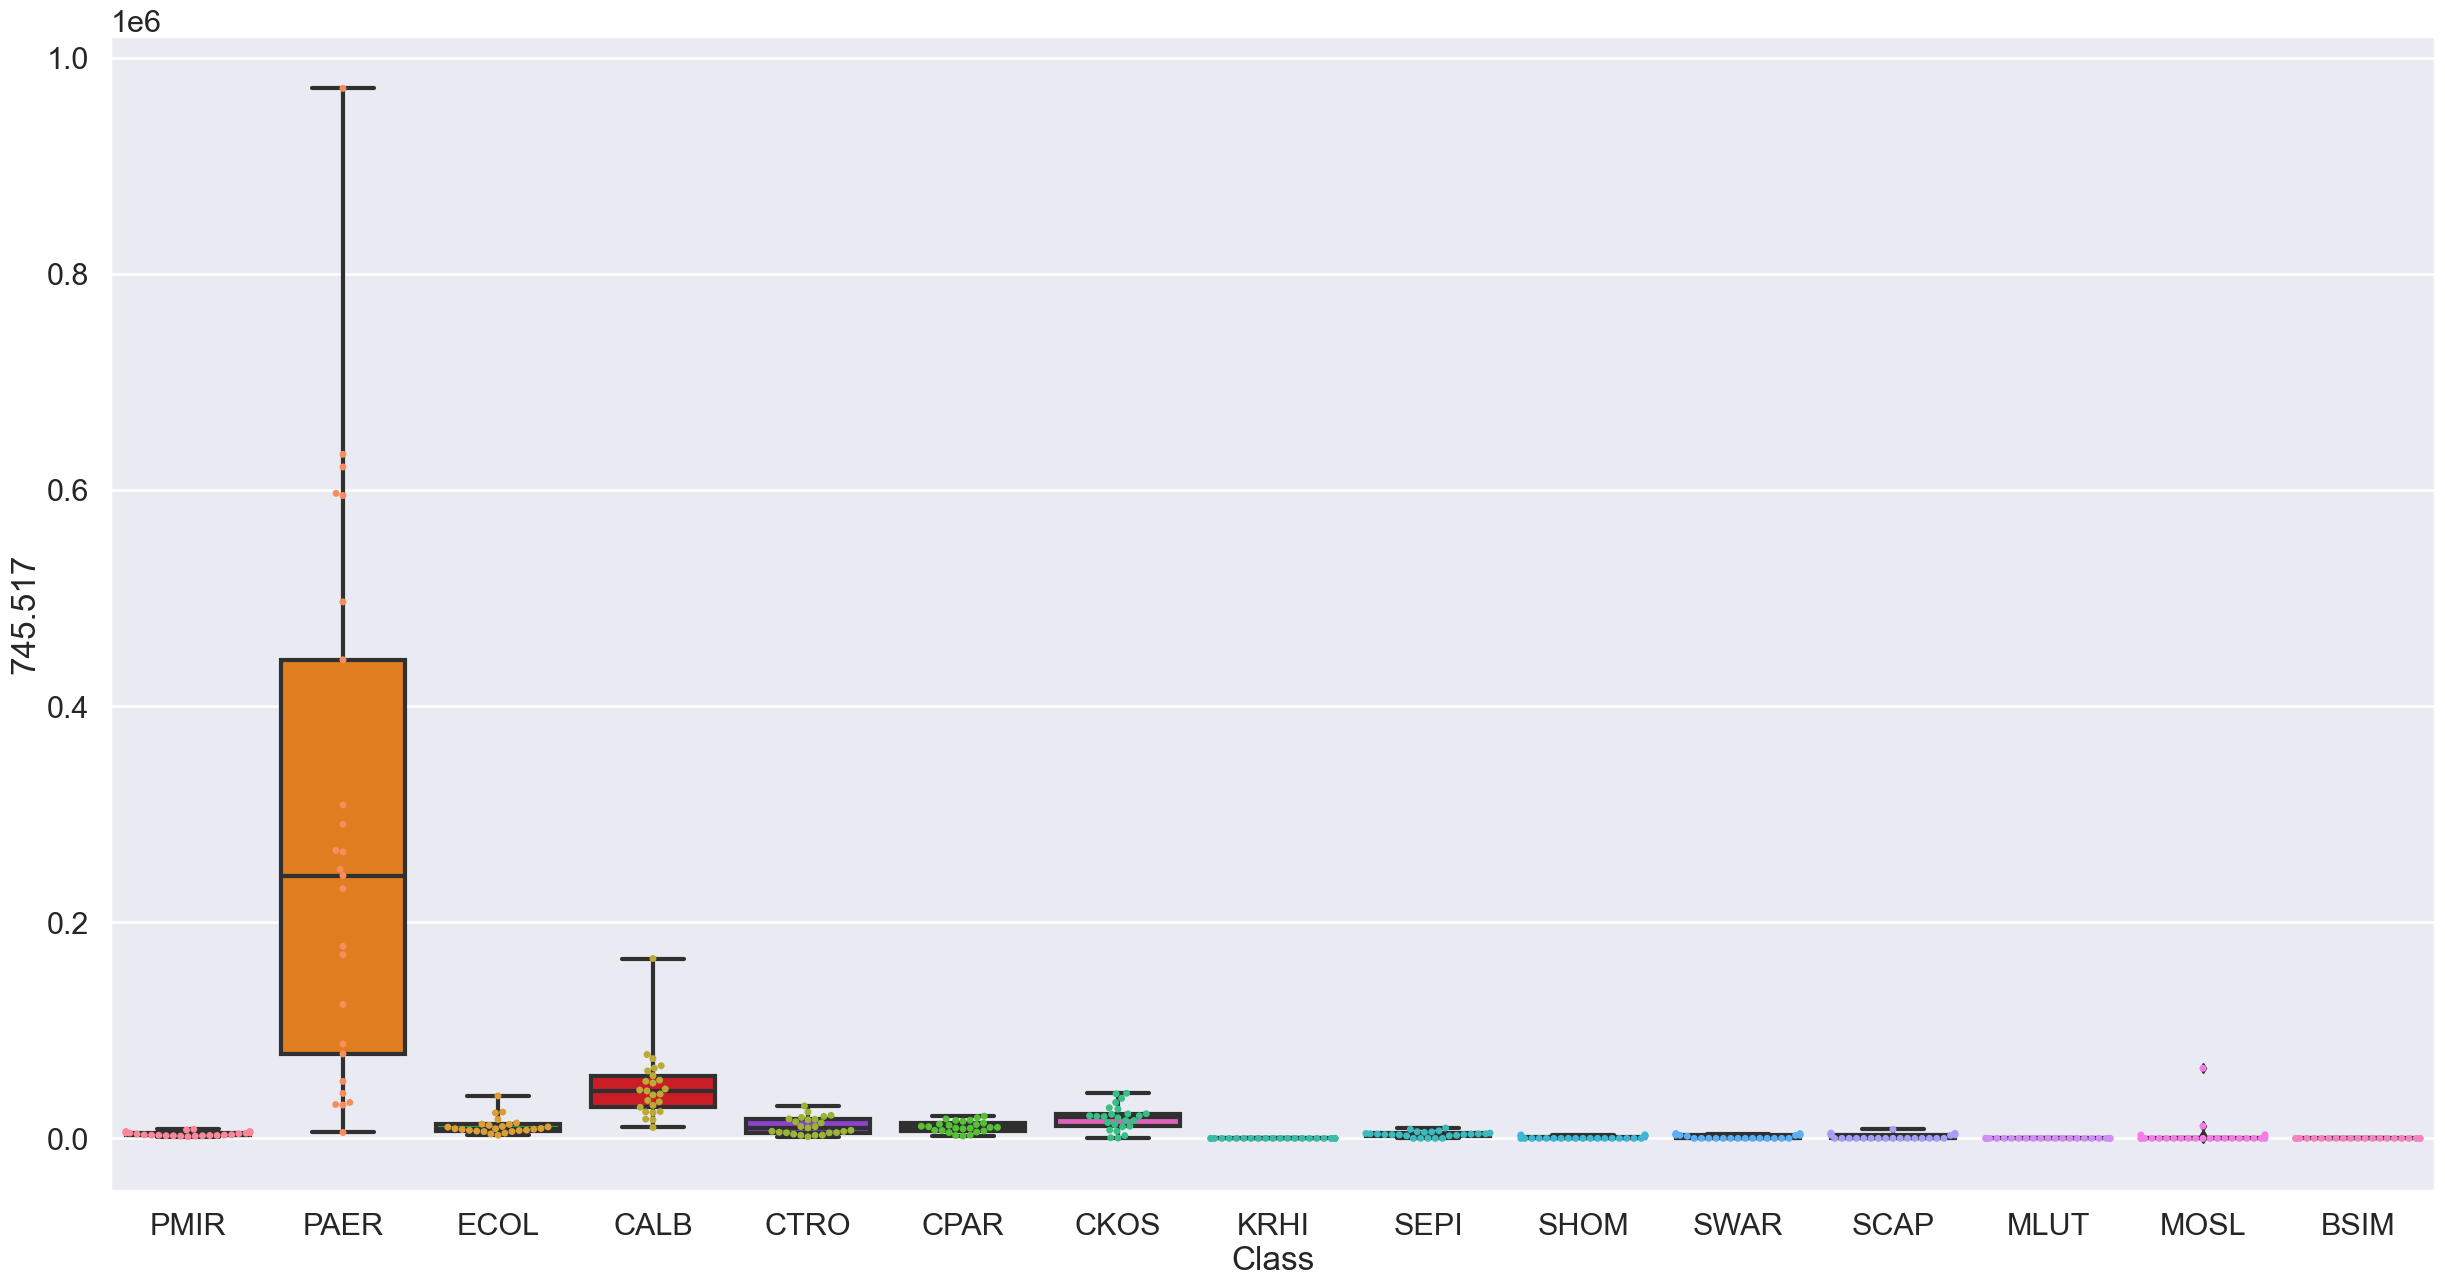

In [49]:
# box_plot([features_from_file], mz, tmp_train,'Label', save=True, savepath = 'D:/_R_Analysis_Random_forest/AZ008_New_Peakpicking_Val1234_Ref/AZ008_OnOff_average_filtering1/Trained_models/Boxplot')
box_plot(['745.517'], mz, tmp_train,'Class', save=False, savepath = 'D:/_R_Analysis_Random_forest/AZ008_New_Peakpicking_Val1234_Ref/AZ008_OnOff_average_filtering1/Trained_models/Boxplot')